In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [3]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

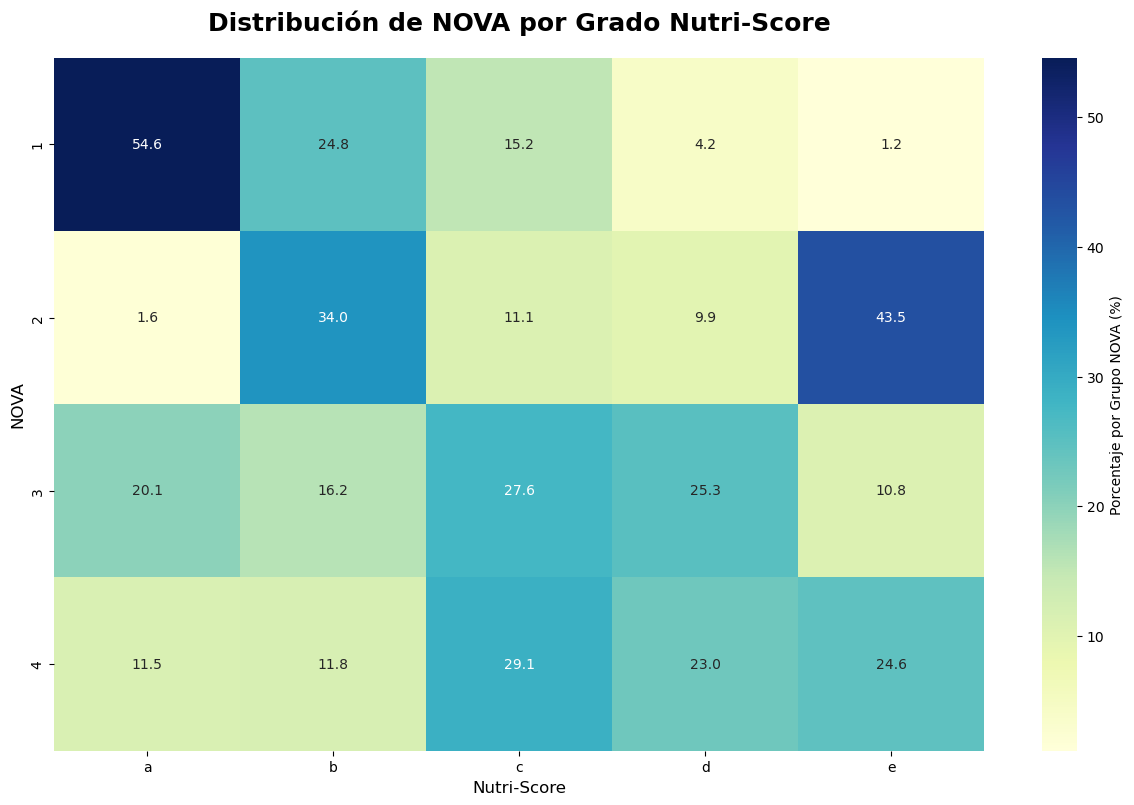

In [4]:
# 1. Creamos un DataFrame temporal filtrando el "ruido"
# Excluimos 'not-applicable', 'unknown' y el grupo 0 de NOVA
df_paradox = foods[
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
    (foods['nova_group'] > 0)
].copy()

# 2. Generamos la tabla cruzada con porcentajes por fila (frecuencia relativa)
cross_tab = pd.crosstab(
    df_paradox['nova_group'], 
    df_paradox['nutriscore_grade'], 
    normalize='index'
) * 100

# 3. Reordenamos las columnas para asegurar la jerarquía A -> E
cross_tab = cross_tab.reindex(columns=['a', 'b', 'c', 'd', 'e'])

# 4. Configuración y visualización del Heatmap
plt.figure(figsize=(15, 9))
sns.heatmap(
    cross_tab, 
    annot=True, 
    cmap="YlGnBu", 
    fmt=".1f", 
    cbar_kws={'label': 'Porcentaje por Grupo NOVA (%)'}
)

plt.title("Distribución de NOVA por Grado Nutri-Score", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("NOVA", fontsize=12)
plt.xlabel("Nutri-Score", fontsize=12)

plt.show()

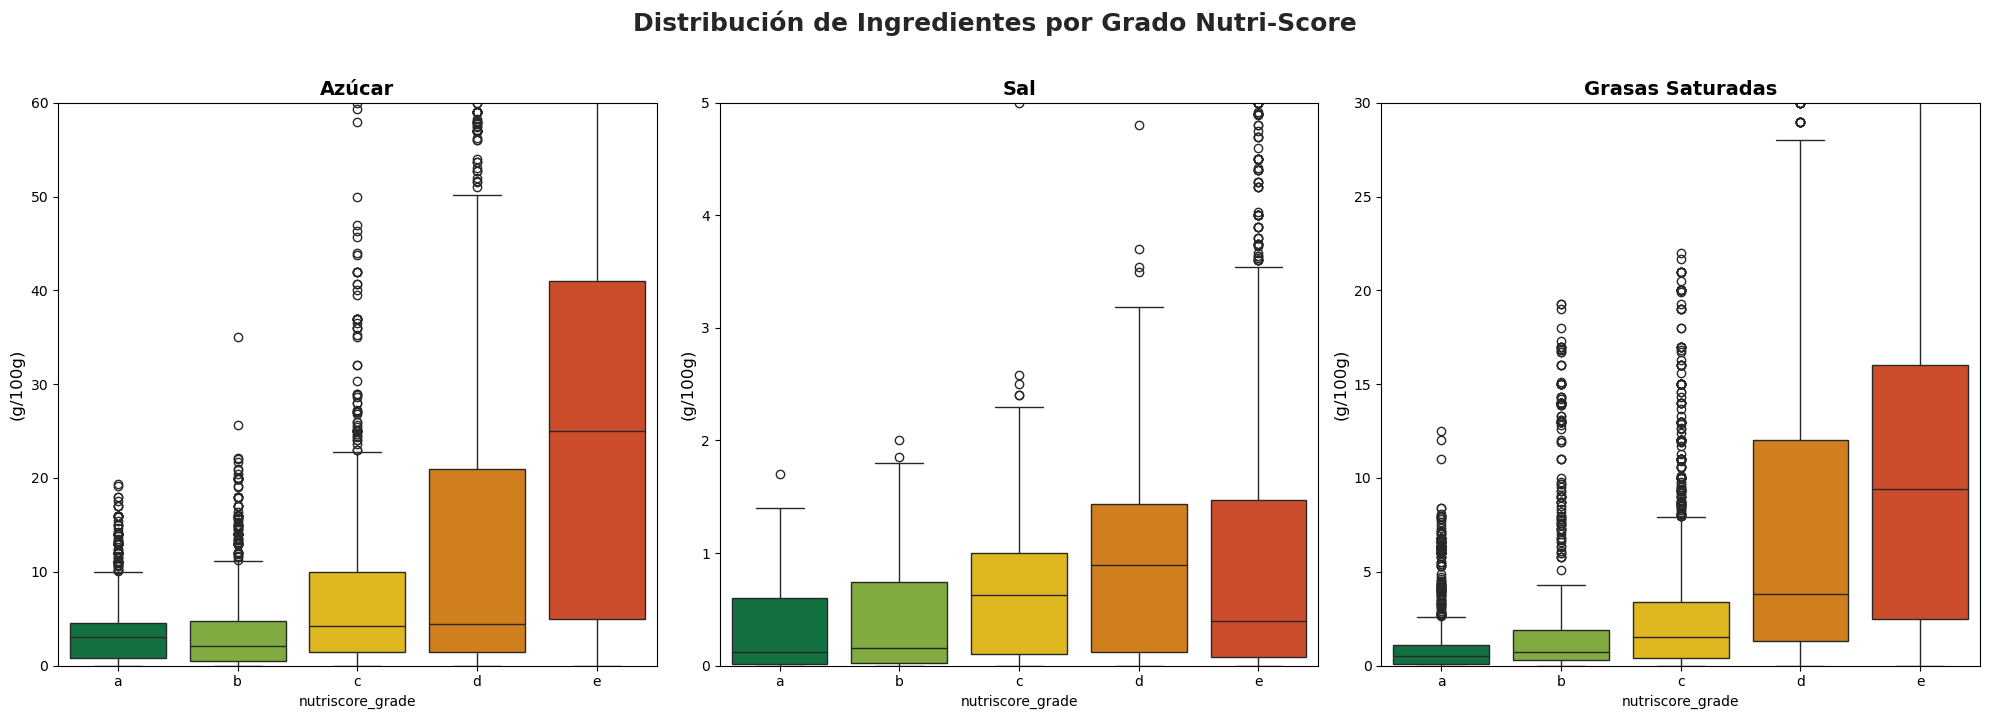

In [5]:
# 1. Filtramos solo los productos con nota válida
df_veracidad = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()

# 2. Definimos la paleta oficial del Nutri-Score 
nutri_palette = {
    'a': '#038141', 
    'b': '#85BB2F', 
    'c': '#FECB02', 
    'd': '#EE8100', 
    'e': '#E63E11'  
}

order = ['a', 'b', 'c', 'd', 'e']

# 3. Configuramos el lienzo
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.set_style("whitegrid")

# Gráfico 1: Azúcares
sns.boxplot(ax=axes[0], x='nutriscore_grade', y='sugars_100g', data=df_veracidad, 
            order=order, palette=nutri_palette, hue='nutriscore_grade', legend=False)
axes[0].set_title('Azúcar', fontsize=14, fontweight='bold')
axes[0].set_ylabel('(g/100g)', fontsize=12)
axes[0].set_ylim(0, 60)

# Gráfico 2: Sal
sns.boxplot(ax=axes[1], x='nutriscore_grade', y='salt_100g', data=df_veracidad, 
            order=order, palette=nutri_palette, hue='nutriscore_grade', legend=False)
axes[1].set_title('Sal', fontsize=14, fontweight='bold')
axes[1].set_ylabel('(g/100g)', fontsize=12)
axes[1].set_ylim(0, 5)

# Gráfico 3: Grasas Saturadas
sns.boxplot(ax=axes[2], x='nutriscore_grade', y='saturated-fat_100g', data=df_veracidad, 
            order=order, palette=nutri_palette, hue='nutriscore_grade', legend=False)
axes[2].set_title('Grasas Saturadas', fontsize=14, fontweight='bold')
axes[2].set_ylabel('(g/100g)', fontsize=12)
axes[2].set_ylim(0, 30)

plt.suptitle("Distribución de Ingredientes por Grado Nutri-Score", 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

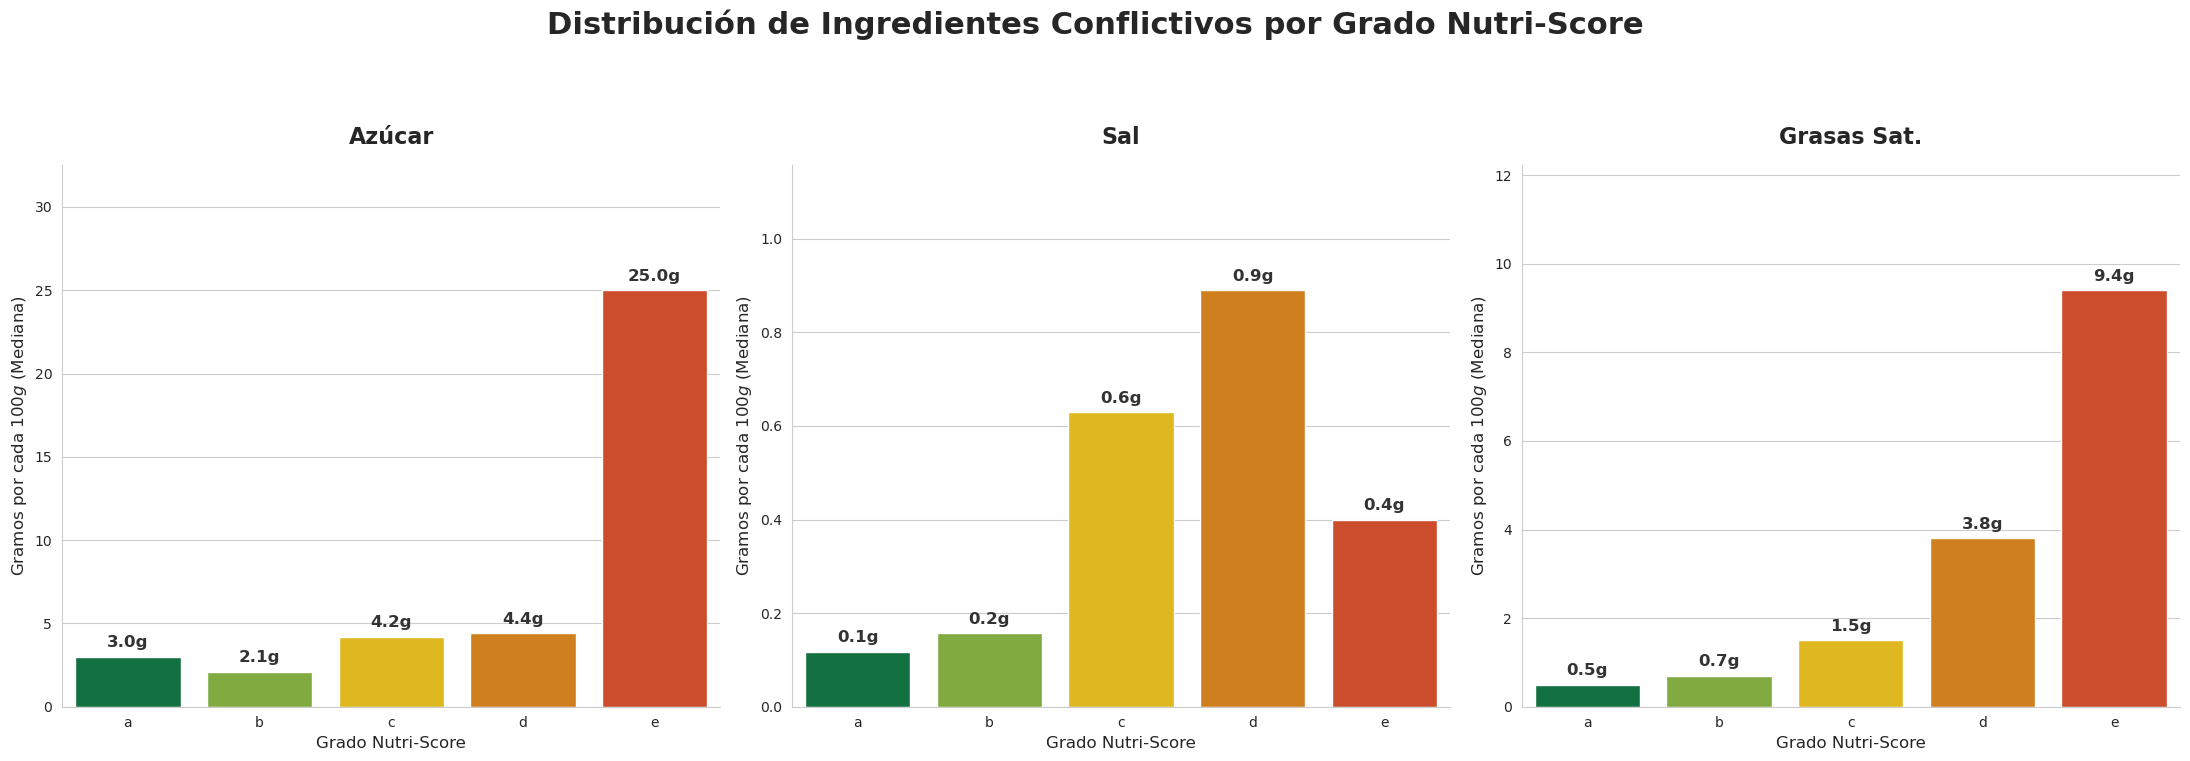

In [6]:
# 1. Preparación de datos: calculamos las medianas por grado
df_veracidad = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()

nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
titulos = ['Azúcar', 'Sal', 'Grasas Sat.']
unidades = ['g', 'g', 'g']

# Agrupamos por mediana
medianas = df_veracidad.groupby('nutriscore_grade')[nutrientes].median().reset_index()

# 2. Configuración estética (Colores oficiales Nutri-Score)
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

nutri_palette = {
    'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 
    'd': '#EE8100', 'e': '#E63E11'
}
order = ['a', 'b', 'c', 'd', 'e']

# 3. Generación de los 3 subplots
for i, nutriente in enumerate(nutrientes):
    ax = sns.barplot(
        ax=axes[i], 
        x='nutriscore_grade', 
        y=nutriente, 
        data=medianas, 
        order=order, 
        palette=nutri_palette, 
        hue='nutriscore_grade', 
        legend=False
    )
    
    # Añadimos etiquetas de valor sobre cada barra
    for p in ax.patches:
        val = p.get_height()
        ax.annotate(f'{val:.1f}{unidades[i]}', 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points', 
                    fontsize=12, fontweight='bold', color='#333333')
    ax.set_title(titulos[i], fontsize=16, pad=15, fontweight='bold')
    ax.set_ylabel(r"Gramos por cada 100$g$ (Mediana)", fontsize=12)
    ax.set_xlabel("Grado Nutri-Score", fontsize=12)
    ax.set_ylim(0, medianas[nutriente].max() * 1.3)
    sns.despine(ax=ax)

plt.suptitle("Distribución de Ingredientes Conflictivos por Grado Nutri-Score", 
             fontsize=22, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

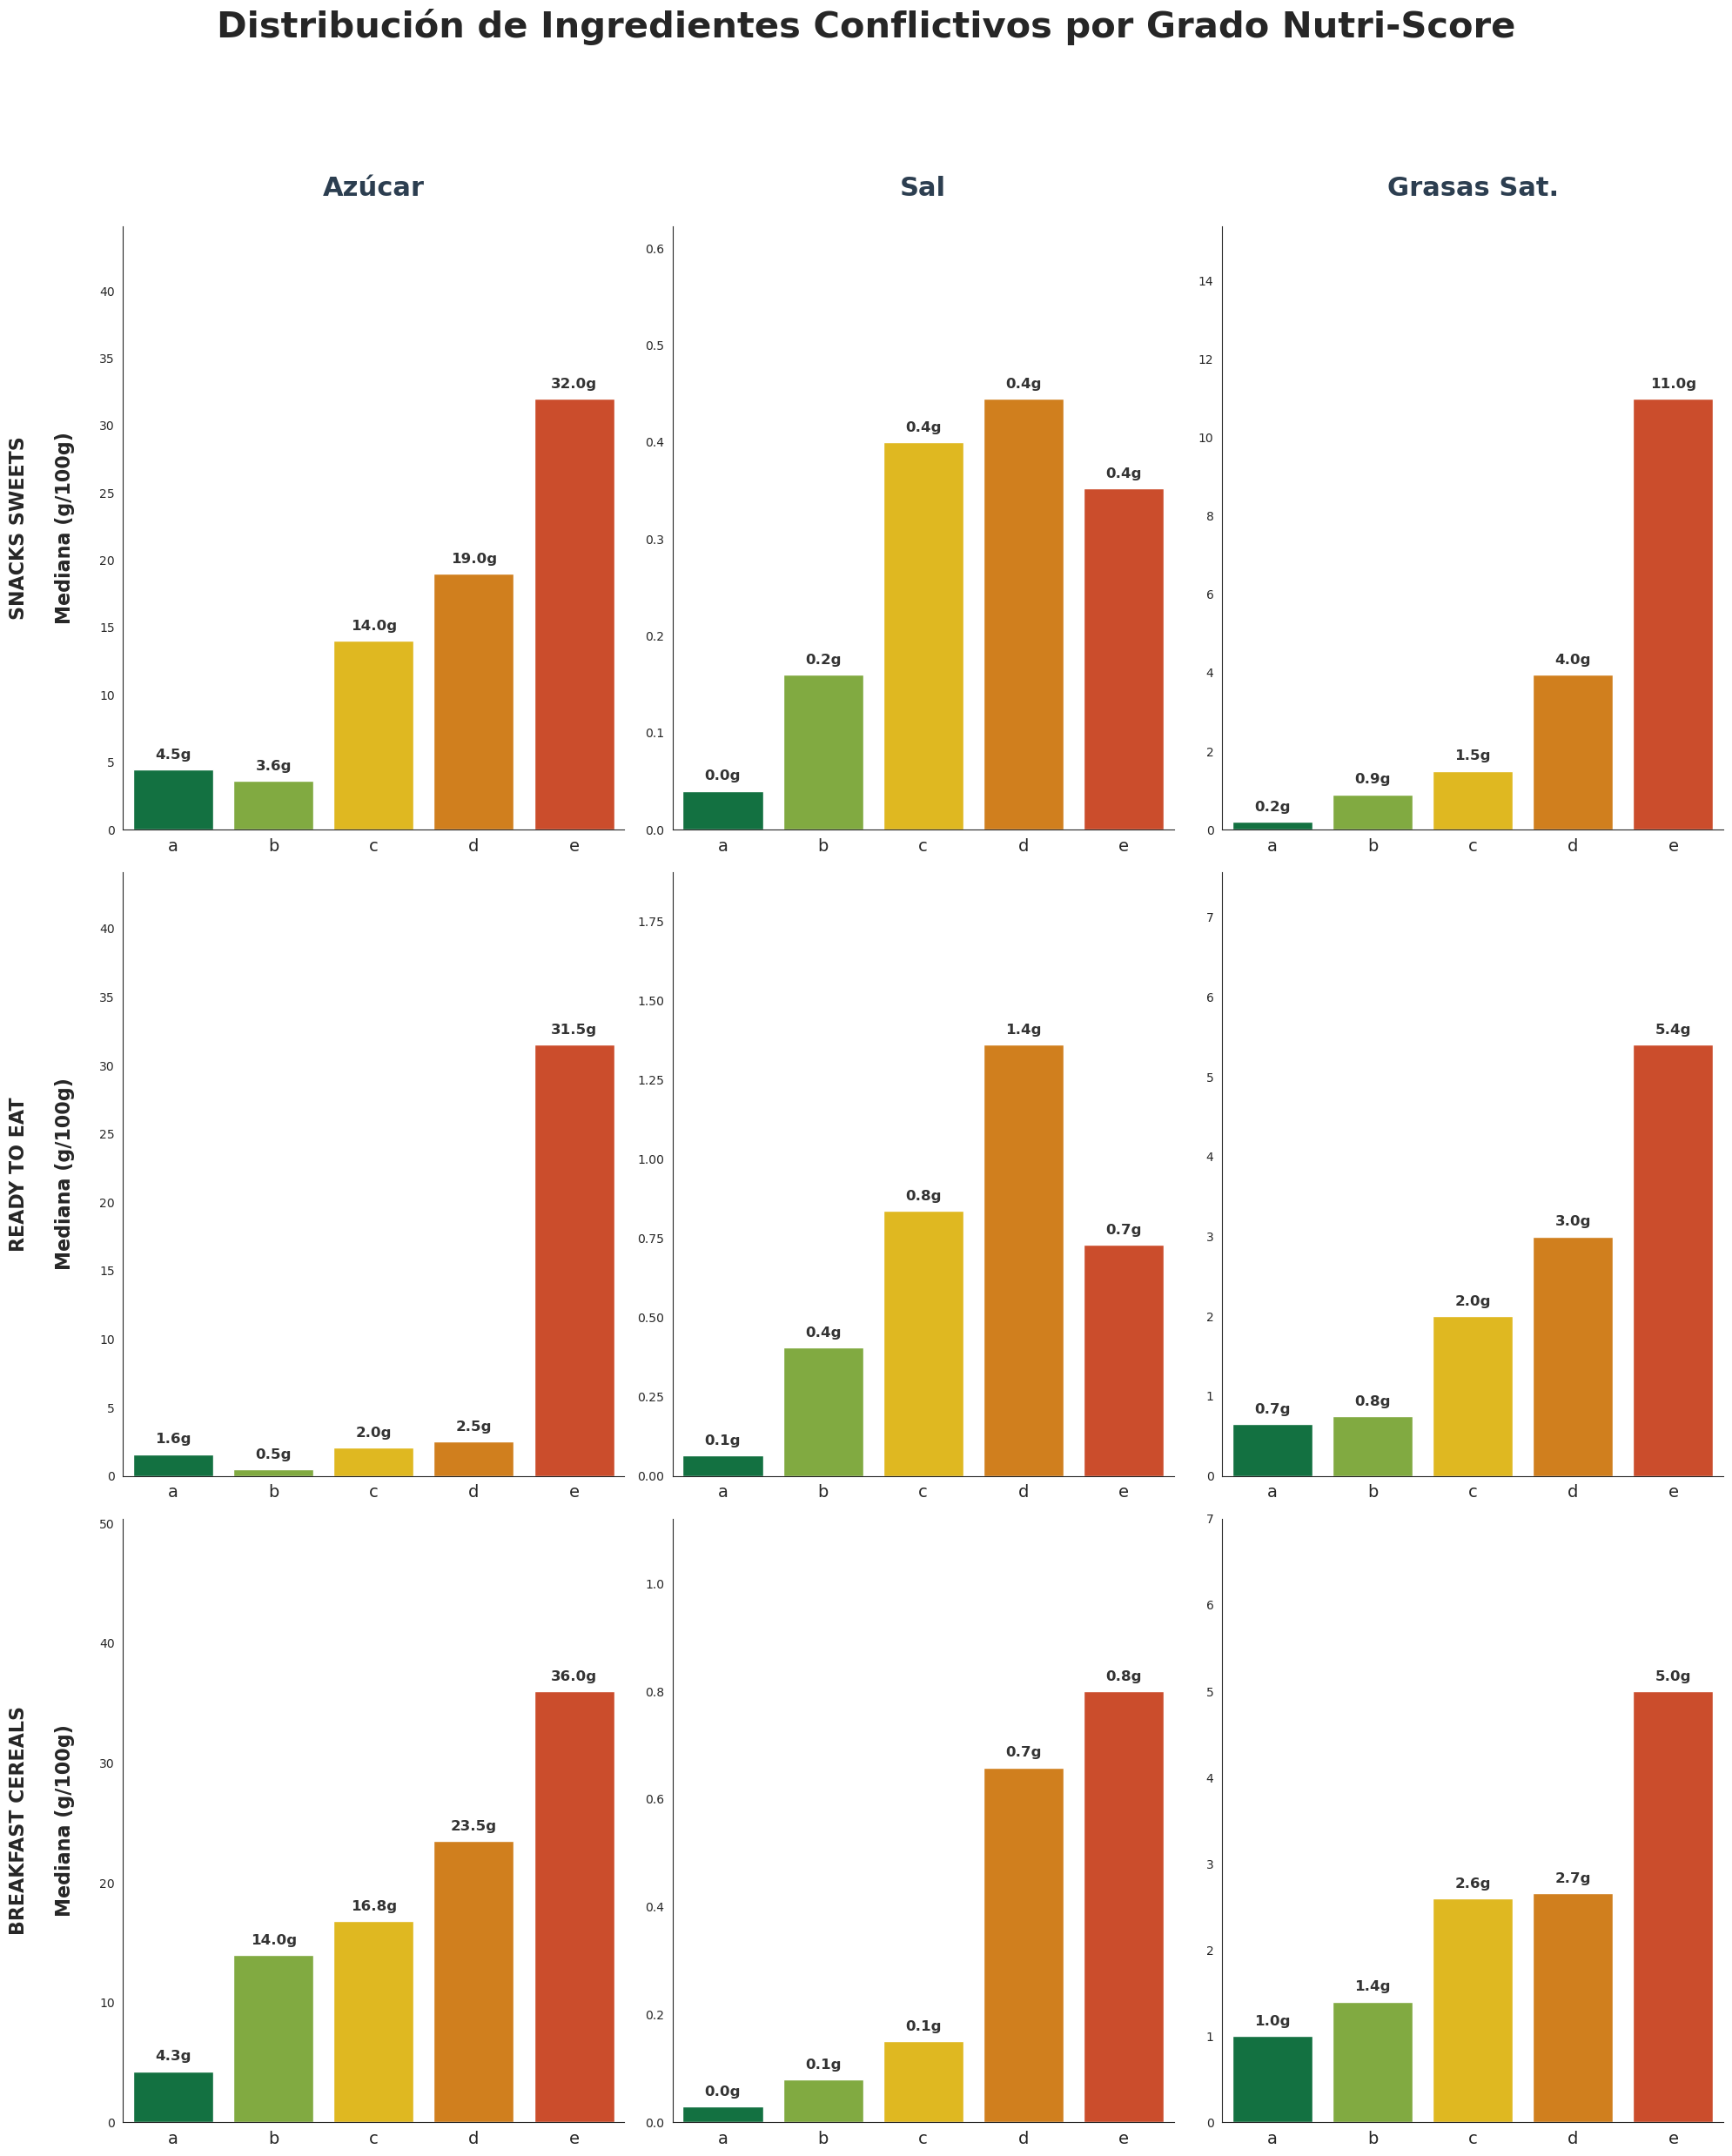

In [7]:
# 1. Configuración de categorías
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals']
nutrientes = ['sugars_100g', 'salt_100g', 'saturated-fat_100g']
unidades = ['g', 'g', 'g']
titulos_nutri = ['Azúcar', 'Sal', 'Grasas Sat.']

# Paleta oficial de Nutri-Score
nutri_palette = {
    'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 
    'd': '#EE8100', 'e': '#E63E11'
}

# 2. Filtramos el dataset
df_plot = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 3. Configuración de la matriz 3x3
sns.set_style("white")
fig, axes = plt.subplots(3, 3, figsize=(20, 24))
order = ['a', 'b', 'c', 'd', 'e']

# 4. Generación de la matriz
for row, cat in enumerate(top_categories):
    for col, nutri in enumerate(nutrientes):
        ax = axes[row, col]
        
        # Filtramos datos y calculamos mediana
        data_subset = df_plot[df_plot['category_unified'] == cat]
        medianas_subset = data_subset.groupby('nutriscore_grade')[nutri].median().reindex(order).reset_index()
        
        # Dibujamos el barplot con la paleta específica
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medianas_subset,
            order=order, palette=nutri_palette, hue='nutriscore_grade', legend=False
        )
        
        # Anotaciones de los valores de la mediana
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val):
                ax.annotate(f'{val:.1f}{unidades[col]}', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 12), textcoords='offset points', 
                            fontsize=12, fontweight='bold', color='#333333')

        # Títulos de columna
        if row == 0:
            ax.set_title(f"{titulos_nutri[col]}", fontsize=22, fontweight='bold', pad=25, color='#2c3e50')
            
        # Etiquetas de fila 
        if col == 0:
            nombre_label = cat.replace('_', ' ').upper()
            ax.set_ylabel(f"{nombre_label}\n\nMediana (g/100g)", fontsize=16, fontweight='bold', labelpad=20)
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelsize=14)
        
        # Ajuste de límites para que las etiquetas no se corten
        max_val = medianas_subset[nutri].max()
        ax.set_ylim(0, max_val * 1.4 if max_val > 0 else 1)
            
        sns.despine(ax=ax, left=False, bottom=False)

# Título principal y ajustes finales
plt.suptitle("Distribución de Ingredientes Conflictivos por Grado Nutri-Score", 
             fontsize=30, fontweight='bold', y=1.03)

plt.tight_layout(rect=[0, 0, 1, 0.98]) 
plt.show()

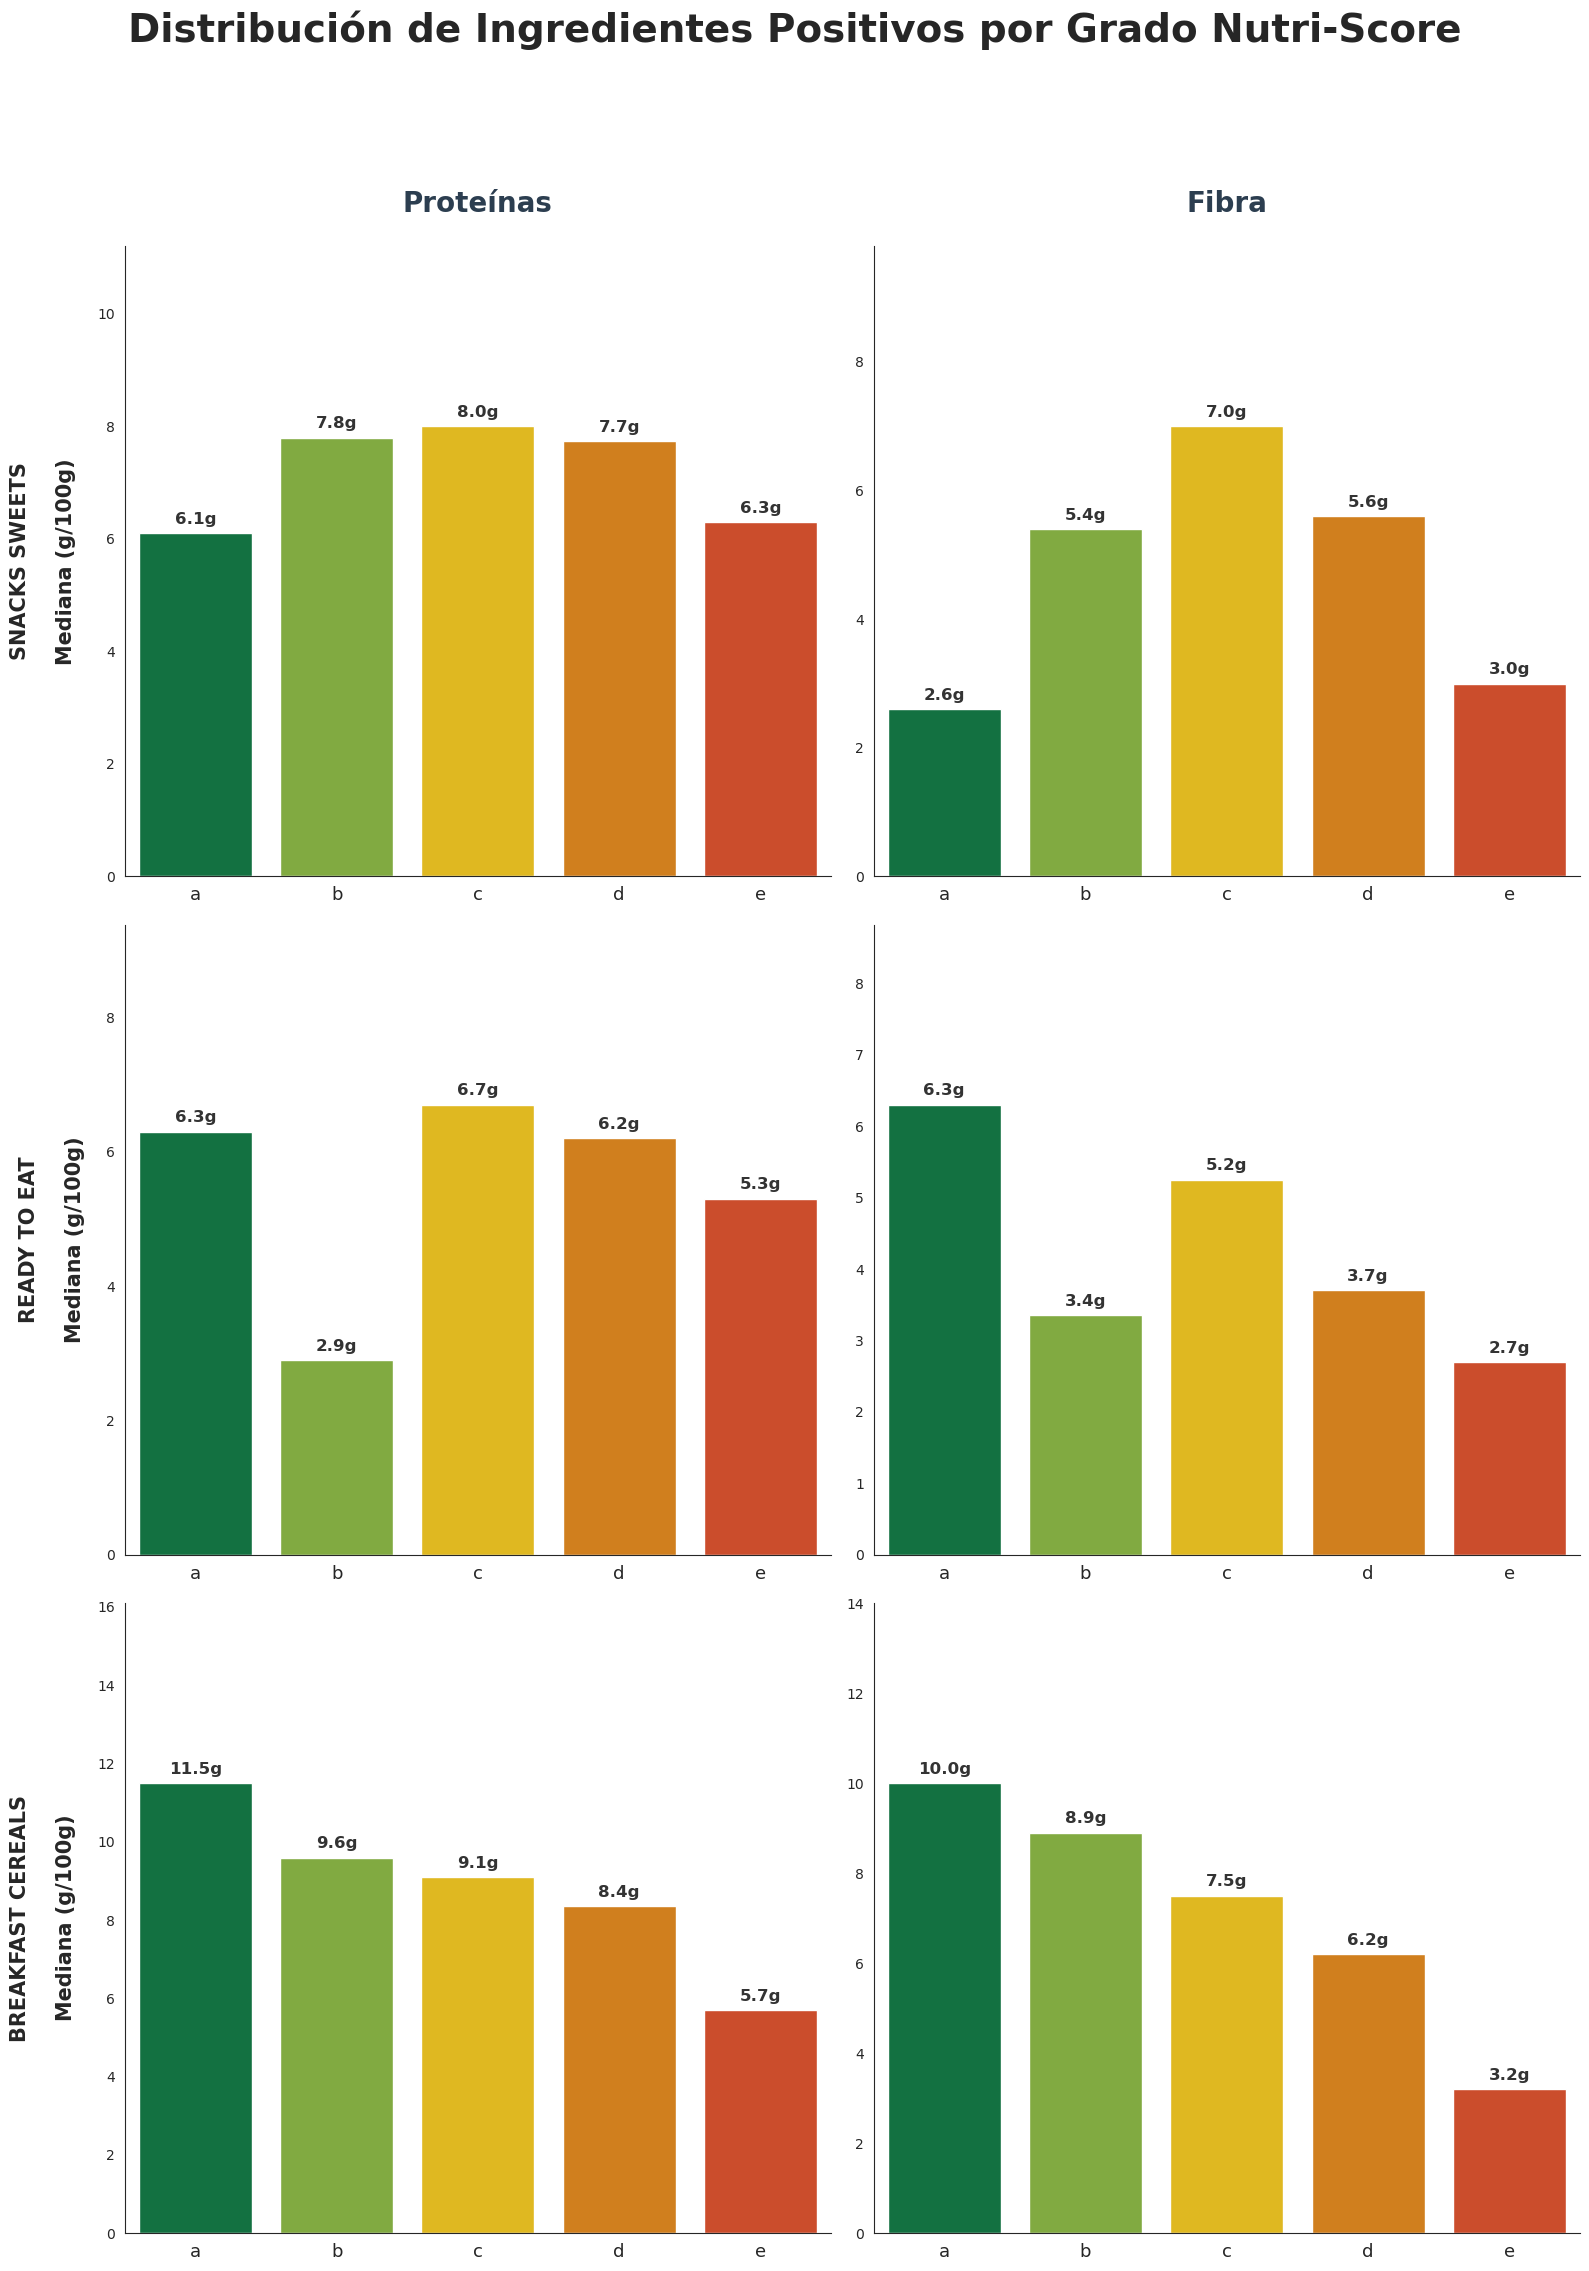

In [8]:
# 1. Configuración de categorías y nutrientes "positivos"
top_categories = ['snacks_sweets', 'ready_to_eat', 'breakfast_cereals']
nutrientes_pos = ['proteins_100g', 'fiber_100g']
titulos_pos = ['Proteínas', 'Fibra']

# Paleta oficial Nutri-Score
nutri_palette = {
    'a': '#038141', 'b': '#85BB2F', 'c': '#FECB02', 
    'd': '#EE8100', 'e': '#E63E11'
}

# Filtramos el dataset
df_pos = foods[
    (foods['category_unified'].isin(top_categories)) & 
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e']))
].copy()

# 2. Configuración de la matriz 4x2
sns.set_style("white")
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
order = ['a', 'b', 'c', 'd', 'e']

# 3. Bucle para generar la matriz
for row, cat in enumerate(top_categories):
    for col, nutri in enumerate(nutrientes_pos):
        ax = axes[row, col]
        
        # Filtramos datos y calculamos la MEDIANA 
        data_subset = df_pos[df_pos['category_unified'] == cat]
        medianas_subset = data_subset.groupby('nutriscore_grade')[nutri].median().reindex(order).reset_index()
        
        # Dibujamos el barplot
        sns.barplot(
            ax=ax, x='nutriscore_grade', y=nutri, data=medianas_subset,
            order=order, palette=nutri_palette, hue='nutriscore_grade', legend=False
        )
        
        # Añadimos etiquetas de valor sobre las barras
        for p in ax.patches:
            val = p.get_height()
            if not pd.isna(val) and val >= 0:
                ax.annotate(f'{val:.1f}g', 
                            (p.get_x() + p.get_width() / 2., val), 
                            ha='center', va='center', 
                            xytext=(0, 10), textcoords='offset points', 
                            fontsize=12, fontweight='bold', color='#333333')

        # Títulos de columna 
        if row == 0:
            ax.set_title(f"{titulos_pos[col]}", fontsize=20, fontweight='bold', pad=25, color='#2c3e50')
            
        # Etiquetas de fila 
        if col == 0:
            nombre_label = cat.replace('_', ' ').upper()
            ax.set_ylabel(f"{nombre_label}\n\nMediana (g/100g)", fontsize=15, fontweight='bold', labelpad=15)
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelsize=13)
        
        max_val = medianas_subset[nutri].max()
        ax.set_ylim(0, max_val * 1.4 if max_val > 0 else 1)
            
        sns.despine(ax=ax)

# Título general
plt.suptitle("Distribución de Ingredientes Positivos por Grado Nutri-Score", 
             fontsize=28, fontweight='bold', y=1.03)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

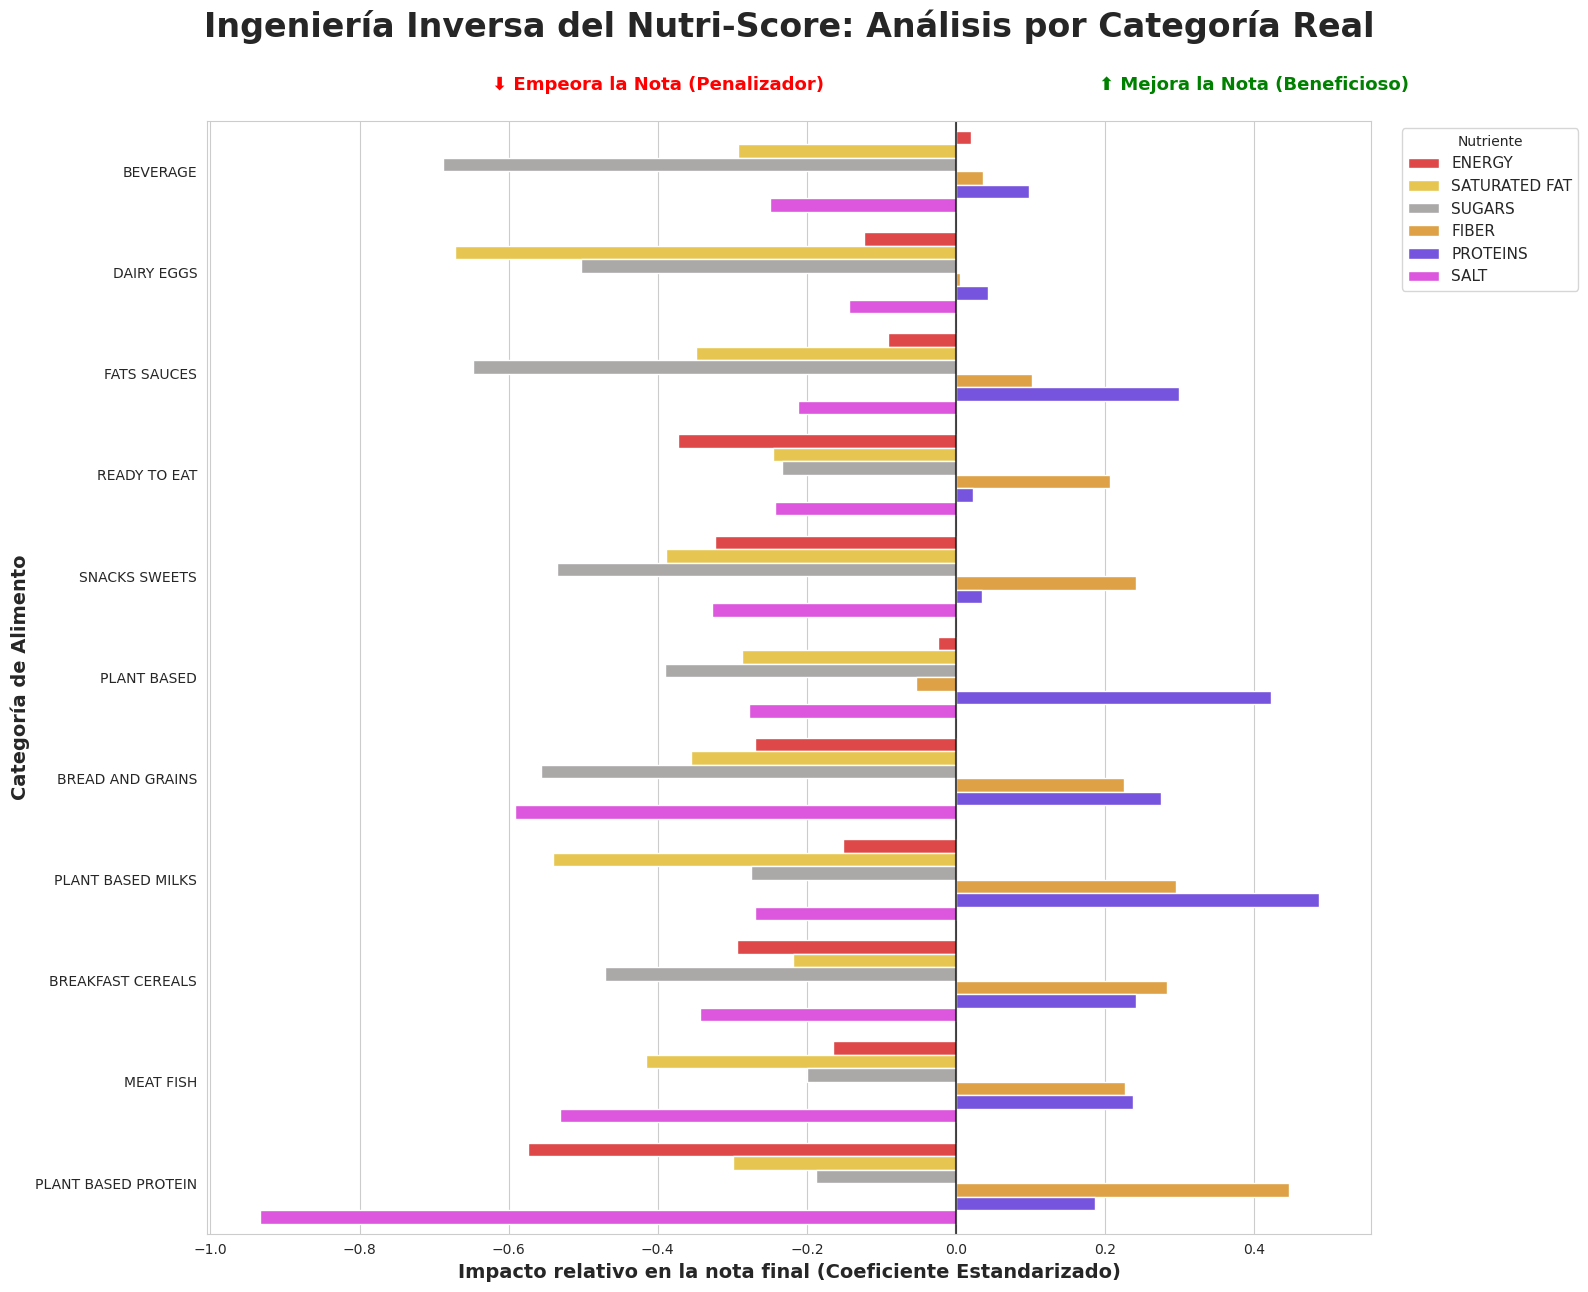

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# 1. Preparación del Dataset (Mantenemos A=5 como mejor nota para que los coeficientes sean intuitivos)
df_reg = foods[foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])].copy()
df_reg['nutri_numeric'] = df_reg['nutriscore_grade'].map({'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1})

# Nutrientes del algoritmo oficial
nutrientes = ['energy-kcal_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']

results = []

# 2. Motor de Regresión Automático por Categoría
# Iteramos sobre todas las categorías únicas (ya no hay "Otros")
for cat in df_reg['category_unified'].unique():
    cat_data = df_reg[df_reg['category_unified'] == cat].dropna(subset=nutrientes + ['nutri_numeric'])
    
    # Filtro de robustez: Solo categorías con más de 15 productos para que la estadística sea fiable
    if len(cat_data) > 15:
        X = cat_data[nutrientes]
        y = cat_data['nutri_numeric']
        
        # Estandarizamos para comparar impactos (ej: ¿pesa más el azúcar que la sal en esta categoría?)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        model = LinearRegression()
        model.fit(X_scaled, y)
        
        for i, nutri in enumerate(nutrientes):
            results.append({
                'category': cat.replace('_', ' ').upper(),
                'nutrient': nutri.replace('-kcal_100g', '').replace('_100g', '').replace('-', ' ').upper(),
                'coefficient': model.coef_[i]
            })

df_results = pd.DataFrame(results)

# 3. Visualización de la Ingeniería Inversa
plt.figure(figsize=(16, 14))
sns.set_style("whitegrid")

# Paleta cromática para diferenciar nutrientes
colores_fuertes = ["#f72f2f", "#ffd437", "#ABA7A7", "#f7a62d", "#6B3DF4", "#F240F5"]

ax = sns.barplot(
    data=df_results, 
    x='coefficient', 
    y='category', 
    hue='nutrient', 
    palette=colores_fuertes
)

# Línea de equilibrio
plt.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

# Títulos y etiquetas
plt.title("Ingeniería Inversa del Nutri-Score: Análisis por Categoría Real", 
          fontsize=24, pad=60, fontweight='bold')
plt.xlabel("Impacto relativo en la nota final (Coeficiente Estandarizado)", fontsize=14, fontweight='bold')
plt.ylabel("Categoría de Alimento", fontsize=14, fontweight='bold')
plt.legend(title="Nutriente", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

# Anotaciones de ayuda interpretativa
plt.text(0.4, -0.8, "⬆️ Mejora la Nota (Beneficioso)", color='green', fontweight='bold', ha='center', fontsize=13)
plt.text(-0.4, -0.8, "⬇️ Empeora la Nota (Penalizador)", color='red', fontweight='bold', ha='center', fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.show()

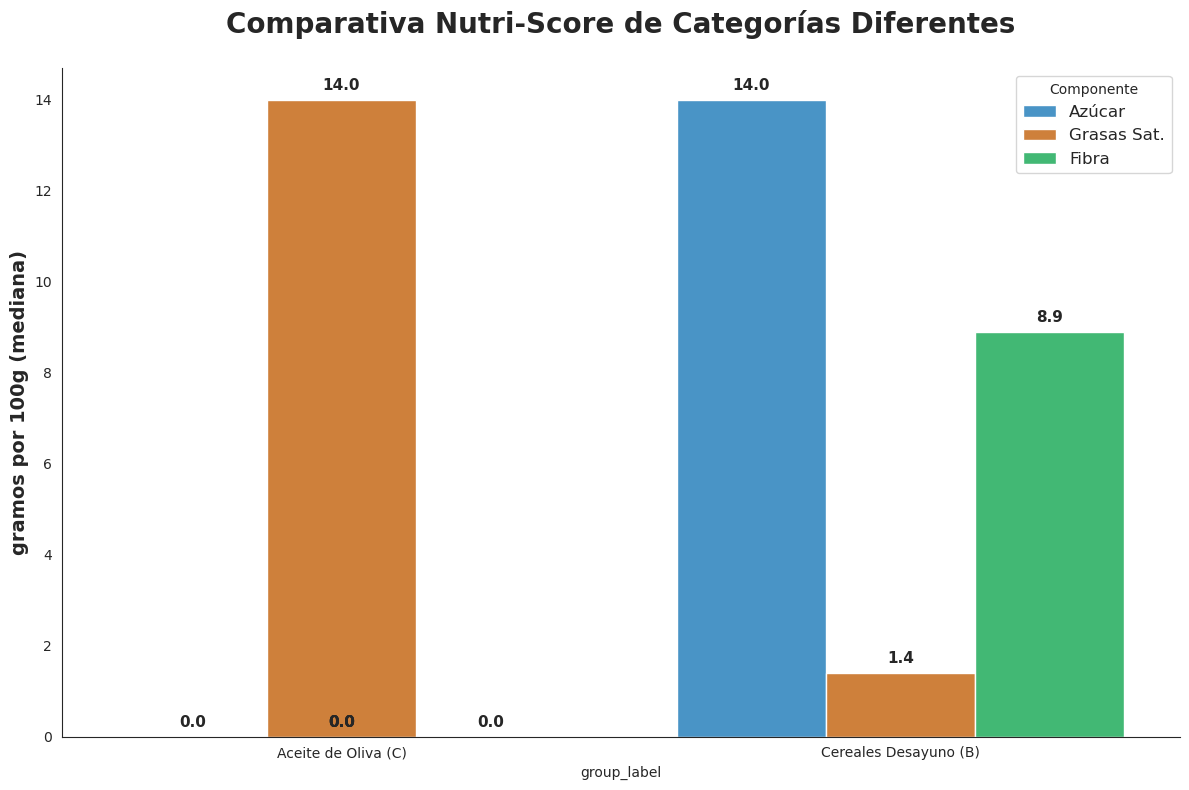

In [10]:
# --- CRÍTICA: ACEITE DE OLIVA VS CEREALES  ---

# 1. Filtrado de los dos grupos enfrentados 
aceites = foods[
    (foods['product_name'].str.contains('olive oil|aceite de oliva|huile d\'olive', case=False, na=False)) &
    (foods['nutriscore_grade'].isin(['b', 'c']))
].copy()
aceites['group_label'] = 'Aceite de Oliva (C)'

cereales = foods[
    (foods['category_unified'] == 'breakfast_cereals') &
    (foods['nutriscore_grade'] == 'b')
].copy()
cereales['group_label'] = 'Cereales Desayuno (B)'

# 2. Preparamos los datos usando MEDIANA
df_comp = pd.concat([aceites, cereales])
nutri_cols = ['sugars_100g', 'saturated-fat_100g', 'fiber_100g']

df_medians = df_comp.groupby('group_label')[nutri_cols].median().reset_index()
df_melted = df_medians.melt(id_vars='group_label', var_name='Nutriente', value_name='g_100g')

# 3. Visualización
plt.figure(figsize=(12, 8))
sns.set_style("white")

paleta_nutri = {
    'sugars_100g': '#3498db', 
    'saturated-fat_100g': '#e67e22', 
    'fiber_100g': '#2ecc71'
}

ax = sns.barplot(
    data=df_melted,
    x='group_label',
    y='g_100g',
    hue='Nutriente',
    palette=paleta_nutri
)

# 4. Estética y Anotaciones 
plt.title("Comparativa Nutri-Score de Categorías Diferentes", 
          fontsize=20, fontweight='bold', pad=25)
plt.ylabel("gramos por 100g (mediana)", fontsize=14, fontweight='bold')

labels = ['Azúcar', 'Grasas Sat.', 'Fibra']
h, _ = ax.get_legend_handles_labels()
plt.legend(h, labels, title="Componente", fontsize=12, loc='upper right')

# Añadimos los valores de la mediana sobre cada barra
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

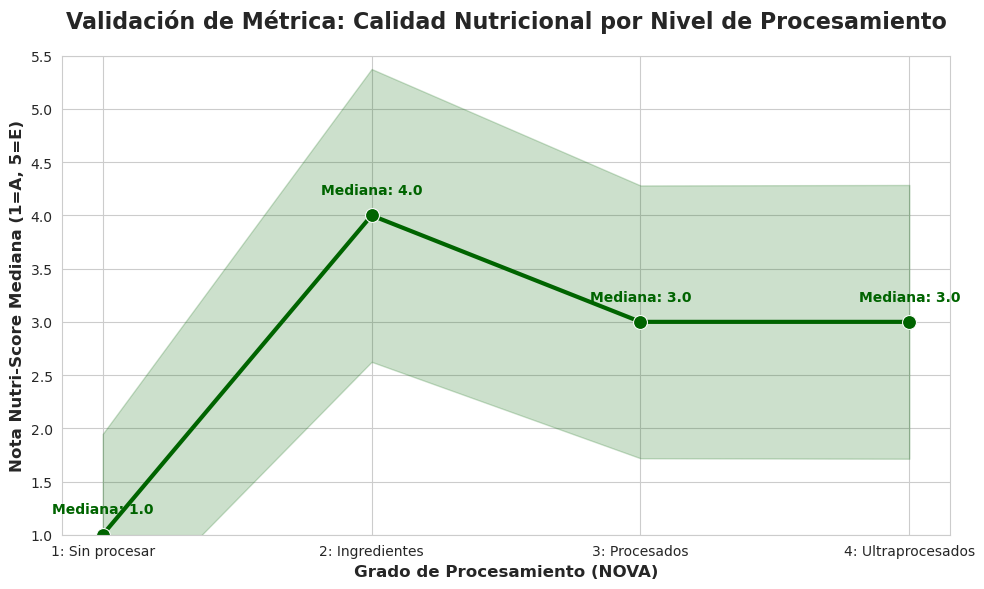

In [11]:
# --- VALIDACIÓN DE ROBUSTEZ: CORRELACIÓN NUTRI-SCORE vs NOVA  ---

# 1. Preparación de datos 
df_val = foods[
    (foods['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])) & 
    (foods['nova_group'].isin([1, 2, 3, 4]))
].copy()

# 2. Conversión a escala numérica
df_val['nutri_numeric'] = df_val['nutriscore_grade'].map({'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5})

# 3. Cálculo de la "Escalera de Procesamiento" usando MEDIANA
resumen_nova = df_val.groupby('nova_group')['nutri_numeric'].agg(['median', 'std', 'count']).reset_index()

# 4. Visualización de la Tendencia
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Dibujamos la línea con el estimador
ax = sns.lineplot(data=df_val, x='nova_group', y='nutri_numeric', 
                  estimator='median', 
                  marker='o', markersize=10, color='darkgreen', linewidth=3, 
                  errorbar='sd') 

# Estética del gráfico 
plt.title("Validación de Métrica: Calidad Nutricional por Nivel de Procesamiento", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Grado de Procesamiento (NOVA)", fontsize=12, fontweight='bold')
plt.ylabel("Nota Nutri-Score Mediana (1=A, 5=E)", fontsize=12, fontweight='bold')
plt.xticks([1, 2, 3, 4], ['1: Sin procesar', '2: Ingredientes', '3: Procesados', '4: Ultraprocesados'])
plt.ylim(1, 5.5) 

# Añadimos etiquetas de valor sobre los puntos
for x, y in zip(resumen_nova['nova_group'], resumen_nova['median']):
    plt.text(x, y + 0.2, f"Mediana: {y:.1f}", ha='center', fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()